# Logit Lens & Activation Patching

Two core mech-interp techniques: **logit lens** (read off "what would the model predict?" from each layer's residual stream) and **activation patching** (swap in clean activations during a corrupted run and see how much the output recovers).

Goal: see *when* the model commits to an answer (logit lens) and *which* layers/components matter for that answer (patching).

TransformerLens + GPT-2 Small, so it runs on a laptop. From the repo root: `uv sync`, then the `.venv` kernel.

## 1. Setup

In [1]:
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer

/Users/hosshonarvar/Documents/Hoss/AI/NN_theory/mechanistic-interpretability/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "gpt2"  # GPT-2 Small
device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained(MODEL_NAME, device=device)
model.eval()
print(f"Model: {MODEL_NAME}, device: {device}, n_layers: {model.cfg.n_layers}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model gpt2 into HookedTransformer
Model: gpt2, device: cpu, n_layers: 12


## 2. Clean vs corrupted prompt

Simple contrast: one prompt leads to the "right" completion (clean), the other to a different one (corrupted), same length. We'll measure how much the model prefers the clean answer over the corrupted one (logit diff) and where that preference is built (logit lens) or restored (patching).

In [3]:
clean_prompt = "The Eiffel Tower is in"   # model should predict Paris-related tokens
corrupted_prompt = "The Colosseum is in"  # model should predict Rome-related tokens

clean_tokens = model.to_tokens(clean_prompt)
corrupted_tokens = model.to_tokens(corrupted_prompt)

# Same token length required for patching.
assert clean_tokens.shape[1] == corrupted_tokens.shape[1], "Prompts must have same token length"
seq_len = clean_tokens.shape[1]
print(f"Clean: '{clean_prompt}' -> {clean_tokens.shape}")
print(f"Corrupted: '{corrupted_prompt}' -> {corrupted_tokens.shape}")

Clean: 'The Eiffel Tower is in' -> torch.Size([1, 8])
Corrupted: 'The Colosseum is in' -> torch.Size([1, 8])


In [4]:
# Final position: where we measure logits (next-token prediction)
position = -1  # last position

# We need *different* answer tokens for clean vs corrupted so logit diff is non-zero.
# Metric is logit(Paris) - logit(Rome), so we need those token ids (not the model's top-1).
clean_answer_token = model.to_tokens(" Paris", prepend_bos=False).squeeze()
clean_answer_token = clean_answer_token.item() if clean_answer_token.dim() == 0 else clean_answer_token[0].item()
corrupted_answer_token = model.to_tokens(" Rome", prepend_bos=False).squeeze()
corrupted_answer_token = corrupted_answer_token.item() if corrupted_answer_token.dim() == 0 else corrupted_answer_token[0].item()

with torch.no_grad():
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, _ = model.run_with_cache(corrupted_tokens)

# What does the model actually predict?
clean_top1 = clean_logits[0, position].argmax().item()
corrupted_top1 = corrupted_logits[0, position].argmax().item()
print(f"Model top-1 clean: '{model.tokenizer.decode([clean_top1])}' (id {clean_top1})")
print(f"Model top-1 corrupted: '{model.tokenizer.decode([corrupted_top1])}' (id {corrupted_top1})")
print(f"Metric: logit(' Paris') - logit(' Rome')  -> clean_answer_token={clean_answer_token}, corrupted_answer_token={corrupted_answer_token}")

Model top-1 clean: ' the' (id 262)
Model top-1 corrupted: ' the' (id 262)
Metric: logit(' Paris') - logit(' Rome')  -> clean_answer_token=6342, corrupted_answer_token=10598


## 3. Logit lens

At each layer we read the residual stream at the last position, hit it with the unembedding `W_U`, and see which token would "win" there. So we're asking: if the model stopped at layer L, what would it predict? That tells us when the representation starts to look like the final answer.

In [5]:
def logit_lens_by_layer(model, cache, position=-1):
    """Returns list of (layer_index, logits_at_pos, top_token_id) for resid_post at each block."""
    results = []
    n_layers = model.cfg.n_layers
    W_U = model.W_U  # (d_model, d_vocab)
    for layer in range(n_layers):
        key = f"blocks.{layer}.hook_resid_post"
        if key not in cache:
            continue
        resid = cache[key]  # (batch, seq, d_model)
        resid_at_pos = resid[0, position, :].unsqueeze(0)  # (1, d_model)
        logits_L = resid_at_pos @ W_U  # (1, d_vocab)
        top_id = logits_L.argmax(dim=-1).item()
        results.append((layer, logits_L.squeeze(0), top_id))
    return results

In [6]:
ll_results = logit_lens_by_layer(model, clean_cache, position=position)
print("Logit lens (top-1 token at last position) by layer:")
for layer, logits_L, top_id in ll_results[:5]:
    print(f"  Layer {layer}: '{model.tokenizer.decode([top_id])}'")
print("  ...")
for layer, logits_L, top_id in ll_results[-3:]:
    print(f"  Layer {layer}: '{model.tokenizer.decode([top_id])}'")

Logit lens (top-1 token at last position) by layer:
  Layer 0: ' order'
  Layer 1: ' order'
  Layer 2: ' order'
  Layer 3: ' accordance'
  Layer 4: 'escap'
  ...
  Layer 9: ' ruins'
  Layer 10: ' ruins'
  Layer 11: ' ruins'


### Logit lens: logit difference at each layer

Same idea, but we track one number: logit(Paris) - logit(Rome) at the last position when we read from each layer. Positive = that layer already prefers Paris; negative = it briefly prefers Rome. The curve shows when the clean run "commits" to the answer.

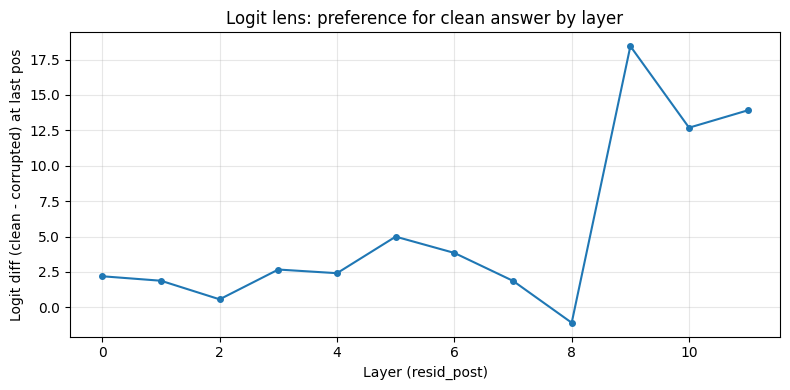

In [7]:
logit_diffs_ll = []
for layer, logits_L, _ in ll_results:
    ld = (logits_L[clean_answer_token] - logits_L[corrupted_answer_token]).item()
    logit_diffs_ll.append((layer, ld))

layers_ll = [x[0] for x in logit_diffs_ll]
diffs_ll = [x[1] for x in logit_diffs_ll]
plt.figure(figsize=(8, 4))
plt.plot(layers_ll, diffs_ll, marker="o", markersize=4)
plt.xlabel("Layer (resid_post)")
plt.ylabel("Logit diff (clean - corrupted) at last pos")
plt.title("Logit lens: preference for clean answer by layer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What this means (logit lens)

We ran the clean prompt; at each layer we're just reading off "Paris vs Rome" from the residual. So the curve is literally *when* that preference shows up. Early layers often haven't decided yet (or even lean the other way); a big jump at some layer means that block did a lot of the work. It's descriptive: we're not intervening, just observing what's already in the stream.


## 4. Activation patching

Run the corrupted forward pass but at one point replace an activation with the clean run’s value; measure how much the logit diff recovers. We do two things: **4a** patch the whole residual at each layer (full recovery at every layer, as expected); **4b** patch smaller pieces (attention or MLP per layer) to see which components matter.

### 4a. Layer-level residual stream patching

Patch the *whole* residual stream at each layer (replace `resid_post` with the clean run’s value) and measure how much the logit diff recovers. Patching effect = (patched_ld - corrupted_ld) / (clean_ld - corrupted_ld). Effect = 1 means full recovery.

In [8]:
clean_ld_full = (clean_logits[0, position, clean_answer_token] - clean_logits[0, position, corrupted_answer_token]).item()
corrupted_ld_full = (corrupted_logits[0, position, clean_answer_token] - corrupted_logits[0, position, corrupted_answer_token]).item()
denom = clean_ld_full - corrupted_ld_full
print(f"Clean logit diff: {clean_ld_full:.3f}")
print(f"Corrupted logit diff: {corrupted_ld_full:.3f}")
print(f"Denominator (clean - corrupted): {denom:.3f}")

Clean logit diff: 1.713
Corrupted logit diff: -1.068
Denominator (clean - corrupted): 2.781


In [9]:
def patch_resid_at_layer(activation, hook):
    """Hook: replace current residual stream with clean one."""
    return clean_cache[hook.name]

patching_effects = []
for layer in range(model.cfg.n_layers):
    hook_name = f"blocks.{layer}.hook_resid_post"
    if hook_name not in clean_cache:
        continue
    patched_logits = model.run_with_hooks(
        corrupted_tokens,
        fwd_hooks=[(hook_name, patch_resid_at_layer)],
    )
    patched_ld = (
        patched_logits[0, position, clean_answer_token] - patched_logits[0, position, corrupted_answer_token]
    ).item()
    effect = (patched_ld - corrupted_ld_full) / denom if abs(denom) > 1e-8 else 0.0
    patching_effects.append((layer, effect))

layers_p = [x[0] for x in patching_effects]
effects_p = [x[1] for x in patching_effects]
print("Patching effect by layer (1 = full recovery):")
for layer, eff in patching_effects:
    print(f"  Layer {layer}: {eff:.3f}")

Patching effect by layer (1 = full recovery):
  Layer 0: 1.000
  Layer 1: 1.000
  Layer 2: 1.000
  Layer 3: 1.000
  Layer 4: 1.000
  Layer 5: 1.000
  Layer 6: 1.000
  Layer 7: 1.000
  Layer 8: 1.000
  Layer 9: 1.000
  Layer 10: 1.000
  Layer 11: 1.000


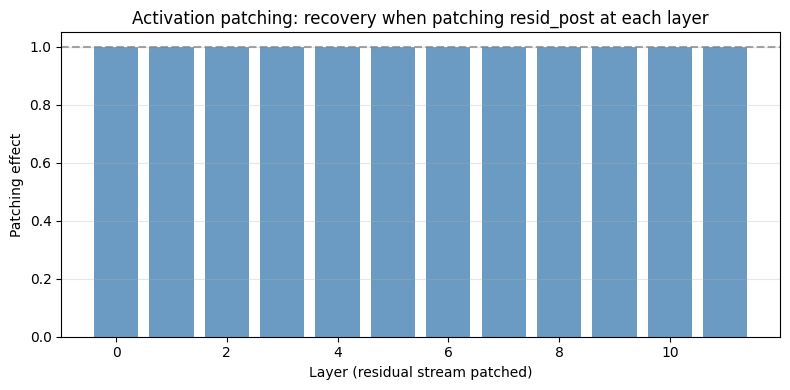

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(layers_p, effects_p, color="steelblue", alpha=0.8)
plt.axhline(y=1.0, color="gray", linestyle="--", alpha=0.7)
plt.xlabel("Layer (residual stream patched)")
plt.ylabel("Patching effect")
plt.title("Activation patching: recovery when patching resid_post at each layer")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### Why residual-stream patching gives effect = 1 at every layer

Patching the *whole* residual at layer L replaces the state every later layer sees. So from L+1 onward the run is identical to the clean run: patched logits equal clean logits. Full recovery at every layer is expected; it doesn't tell us which layer matters. For that we patch smaller pieces (next).


### 4b. Component-level patching (attention and MLP)

Patch only one layer's post-attention residual or MLP output at a time. We're not replacing the full state, so the effect varies by layer and shows which components matter for this contrast.


In [11]:
def make_patch_hook(clean_cache, hook_name):
    """Return a hook that patches the current activation with clean_cache[hook_name]."""
    def patch_hook(activation, hook):
        return clean_cache[hook.name]
    return patch_hook

# Cache keys depend on TransformerLens version and use_attn_result.
cache_keys = list(clean_cache.keys())
# Per-layer keys: attn (hook_result, hook_attn_out, or resid_mid), MLP (hook_mlp_out).
attn_key_for_layer = {}
mlp_key_for_layer = {}
for layer in range(model.cfg.n_layers):
    prefix = f"blocks.{layer}."
    for k in cache_keys:
        if not k.startswith(prefix):
            continue
        if "resid_mid" in k:
            attn_key_for_layer.setdefault(layer, k)  # resid_mid = after attn (always cached)
        if ".attn." in k and ("hook_result" in k or "attn_out" in k or "hook_attn" in k):
            attn_key_for_layer[layer] = k  # actual attn output when present
        if ".mlp." in k and ("mlp_out" in k or "hook_mlp" in k):
            mlp_key_for_layer[layer] = k

# Standard TransformerLens hook names.
cache_set = set(cache_keys)
for layer in range(model.cfg.n_layers):
    if layer not in attn_key_for_layer:
        for candidate in [f"blocks.{layer}.hook_resid_mid", f"blocks.{layer}.attn.hook_result", f"blocks.{layer}.attn.hook_attn_out"]:
            if candidate in cache_set:
                attn_key_for_layer[layer] = candidate
                break
    if layer not in mlp_key_for_layer:
        for candidate in [f"blocks.{layer}.mlp.hook_mlp_out"]:
            if candidate in cache_set:
                mlp_key_for_layer[layer] = candidate
                break
print(f"Found {len(attn_key_for_layer)} layer keys for attn, {len(mlp_key_for_layer)} for mlp.")
if not attn_key_for_layer and not mlp_key_for_layer:
    print("No attn/mlp keys found. Cache keys (first 40):", cache_keys[:40])
effects_attn = []
effects_mlp = []
for layer in range(model.cfg.n_layers):
    for key_dict, effects_list in [(attn_key_for_layer, effects_attn), (mlp_key_for_layer, effects_mlp)]:
        hook_name = key_dict.get(layer)
        if hook_name is None:
            continue
        patched_logits = model.run_with_hooks(
            corrupted_tokens,
            fwd_hooks=[(hook_name, make_patch_hook(clean_cache, hook_name))],
        )
        patched_ld = (
            patched_logits[0, position, clean_answer_token]
            - patched_logits[0, position, corrupted_answer_token]
        ).item()
        effect = (patched_ld - corrupted_ld_full) / denom if abs(denom) > 1e-8 else 0.0
        effects_list.append((layer, effect))

layers_attn = [x[0] for x in effects_attn]
eff_attn = [x[1] for x in effects_attn]
layers_mlp = [x[0] for x in effects_mlp]
eff_mlp = [x[1] for x in effects_mlp]
print("Attention patching effect by layer:")
for layer, e in effects_attn:
    print(f"  Layer {layer}: {e:.3f}")
print("\nMLP patching effect by layer:")
if effects_mlp:
    for layer, e in effects_mlp:
        print(f"  Layer {layer}: {e:.3f}")
else:
    print("  (none: MLP output not in default cache; only attn/resid_mid is cached)")

Found 12 layer keys for attn, 0 for mlp.
Attention patching effect by layer:
  Layer 0: 0.028
  Layer 1: 0.036
  Layer 2: -0.001
  Layer 3: -0.023
  Layer 4: -0.064
  Layer 5: -0.082
  Layer 6: -0.016
  Layer 7: 0.009
  Layer 8: -0.072
  Layer 9: 0.072
  Layer 10: 0.013
  Layer 11: 0.035

MLP patching effect by layer:
  (none: MLP output not in default cache; only attn/resid_mid is cached)


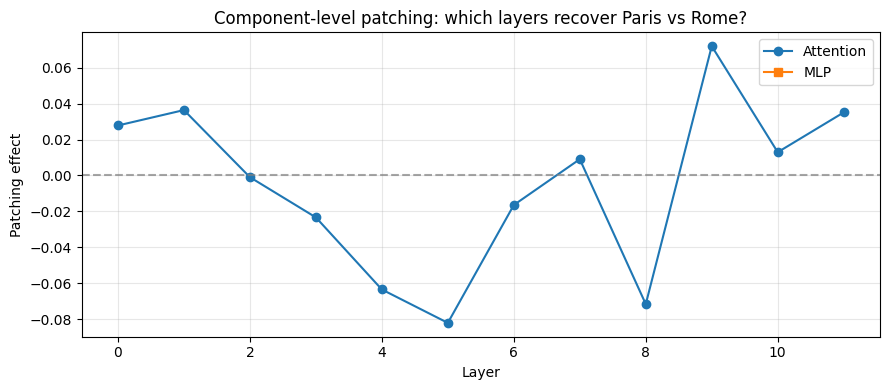

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(layers_attn, eff_attn, marker="o", label="Attention", color="C0")
plt.plot(layers_mlp, eff_mlp, marker="s", label="MLP", color="C1")
plt.axhline(y=0, color="gray", linestyle="--", alpha=0.7)
plt.xlabel("Layer")
plt.ylabel("Patching effect")
plt.title("Component-level patching: which layers recover Paris vs Rome?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What we see (component-level patching)

The code checks which cache keys exist: we get 12 attn (post-attention residual, resid_mid) and often 0 mlp, because MLP output may not be cached by default. So we usually only plot the attention curve.

Positive effect at a layer: replacing that layer's post-attention state with the clean run's pushes the prediction toward Paris. Negative: swapping in clean actually pushes toward Rome (the corrupted state at that layer was partly helping Rome). Near zero: that layer's contribution doesn't matter much for this contrast. Effects are small because we're patching one layer's contribution, not the full residual.


## 5. Summary

**Logit lens:** Read "Paris vs Rome" from the residual at each layer; the curve shows when that preference appears (descriptive, no intervention).

**Activation patching:** Replace activations with clean run's; measure recovery. Full-residual patching gives effect = 1 everywhere (we replace the whole state). Component-level patching (one layer's attn or MLP) shows which layers/components actually matter for this contrast.
